In [28]:
! pip install torchmetrics

In [40]:
pip install transformers huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [29]:
! pip install transformers timm termcolor torchmetrics einops

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

from pathlib import Path

In [31]:
import transformers
import timm
import torchmetrics
import einops
import termcolor

print("All packages installed")

All packages installed


In [44]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(DEVICE)

cuda


In [45]:
DINO_CHECKPOINT = Path(
    r"C:\Users\KRITHI S KULAL\Desktop\TECH\UNET+HYBRID_MODEL\checkpoints\dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
)

print(
    DINO_CHECKPOINT.exists()
)

print(
    DINO_CHECKPOINT
)

True
C:\Users\KRITHI S KULAL\Desktop\TECH\UNET+HYBRID_MODEL\checkpoints\dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


In [46]:
import torch

dinov3 = torch.hub.load(
    "facebookresearch/dinov3",
    "dinov3_vitb16",
    pretrained=False
)

print(type(dinov3))

Using cache found in C:\Users\KRITHI S KULAL/.cache\torch\hub\facebookresearch_dinov3_main


<class 'dinov3.models.vision_transformer.DinoVisionTransformer'>


In [47]:
pretrained=False

In [48]:
checkpoint = torch.load(
    DINO_CHECKPOINT,
    map_location="cpu"
)

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print(checkpoint.keys())

<class 'collections.OrderedDict'>
odict_keys(['cls_token', 'storage_tokens', 'mask_token', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'rope_embed.periods', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.qkv.bias_mask', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.qkv.bias_mask', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.ls1.gamma', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.fc1.weight', 'blocks.1.mlp.fc1.bias', 'blocks.1.mlp.fc2.weight', 'blocks.1.mlp.fc2.bias', 'blocks.1.ls2.gamma', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qk

In [49]:
missing_keys, unexpected_keys = (
    dinov3.load_state_dict(
        checkpoint,
        strict=False
    )
)

print(
    "Missing Keys:",
    len(missing_keys)
)

print(
    "Unexpected Keys:",
    len(unexpected_keys)
)

Missing Keys: 0
Unexpected Keys: 0


In [50]:
dinov3 = dinov3.to(
    DEVICE
)

dinov3.eval()

for param in dinov3.parameters():

    param.requires_grad = False

print(
    "DINOv3 Frozen"
)

DINOv3 Frozen


In [51]:
trainable_params = sum(
    p.numel()
    for p in dinov3.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in dinov3.parameters()
)

print(
    "Trainable:",
    trainable_params
)

print(
    "Total:",
    f"{total_params:,}"
)

Trainable: 0
Total: 85,669,632


In [52]:
dummy = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    output = dinov3(
        dummy
    )

print(
    type(output)
)

if isinstance(
    output,
    dict
):
    print(
        output.keys()
    )
else:
    print(
        output.shape
    )

<class 'torch.Tensor'>
torch.Size([1, 768])


In [53]:
print(dinov3)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    

In [54]:
dummy = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    features = dinov3.forward_features(
        dummy
    )

print(type(features))

if isinstance(features, dict):

    print(features.keys())

else:

    print(features.shape)

<class 'dict'>
dict_keys(['x_norm_clstoken', 'x_storage_tokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


In [56]:
dummy = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    features = dinov3.forward_features(
        dummy
    )

patch_tokens = features[
    "x_norm_patchtokens"
]

print(
    patch_tokens.shape
)

torch.Size([1, 64, 768])


In [57]:
dummy = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    features = dinov3.forward_features(
        dummy
    )

patch_tokens = features[
    "x_norm_patchtokens"
]

feature_map = (
    patch_tokens
    .permute(0, 2, 1)
    .reshape(
        1,
        768,
        8,
        8
    )
)

print(
    feature_map.shape
)

torch.Size([1, 768, 8, 8])


In [58]:
class DINOv3SegmentationHead(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                768,
                512,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                512,
                256,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                1,
                kernel_size=1
            )
        )

    def forward(
        self,
        x
    ):

        return self.decoder(x)

In [59]:
head = DINOv3SegmentationHead().to(
    DEVICE
)

dummy_feature = torch.randn(
    2,
    768,
    8,
    8
).to(DEVICE)

with torch.no_grad():

    output = head(
        dummy_feature
    )

print(
    output.shape
)

torch.Size([2, 1, 128, 128])


In [60]:
from pathlib import Path

PROJECT_ROOT = Path("../")

TRAIN_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/train/images"
)

VAL_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/val/images"
)

TEST_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/images"
)

TRAIN_DINO_DIR = (
    PROJECT_ROOT /
    "dataset/dinov3_embeddings/train"
)

VAL_DINO_DIR = (
    PROJECT_ROOT /
    "dataset/dinov3_embeddings/val"
)

TEST_DINO_DIR = (
    PROJECT_ROOT /
    "dataset/dinov3_embeddings/test"
)

TRAIN_DINO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VAL_DINO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEST_DINO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Directories Created")

Directories Created


In [61]:
print(TRAIN_DINO_DIR)
print(VAL_DINO_DIR)
print(TEST_DINO_DIR)

..\dataset\dinov3_embeddings\train
..\dataset\dinov3_embeddings\val
..\dataset\dinov3_embeddings\test


In [62]:
import numpy as np
from pathlib import Path

In [63]:
sample_path = sorted(
    TRAIN_RGB_DIR.glob("*.npy")
)[0]

print(sample_path)

..\dataset\processed\STRUM\train\images\EMSR279_03ALFARO_17_16_1_1.npy


In [64]:
image = np.load(
    sample_path
).astype(np.float32)

print(image.shape)
print(image.dtype)

(3, 128, 128)
float32


In [65]:
image_tensor = torch.tensor(
    image,
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

print(
    image_tensor.shape
)

torch.Size([1, 3, 128, 128])


In [66]:
with torch.no_grad():

    features = dinov3.forward_features(
        image_tensor
    )

patch_tokens = features[
    "x_norm_patchtokens"
]

print(
    patch_tokens.shape
)

torch.Size([1, 64, 768])


In [67]:
embedding = (
    patch_tokens
    .permute(0, 2, 1)
    .reshape(
        1,
        768,
        8,
        8
    )
)

print(
    embedding.shape
)

torch.Size([1, 768, 8, 8])


In [68]:
print(
    embedding.min().item()
)

print(
    embedding.max().item()
)

print(
    embedding.mean().item()
)

-5.129708766937256
2.403176784515381
0.0005763620138168335


In [69]:
from tqdm import tqdm
import numpy as np
import torch


def generate_dino_embeddings(
    image_dir,
    save_dir,
    dinov3,
    device
):

    image_paths = sorted(
        image_dir.glob("*.npy")
    )

    print(
        f"Found {len(image_paths)} images"
    )

    dinov3.eval()

    with torch.no_grad():

        for image_path in tqdm(image_paths):

            image = np.load(
                image_path
            ).astype(np.float32)

            image_tensor = torch.tensor(
                image,
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            features = dinov3.forward_features(
                image_tensor
            )

            patch_tokens = features[
                "x_norm_patchtokens"
            ]

            embedding = (
                patch_tokens
                .permute(0, 2, 1)
                .reshape(
                    768,
                    8,
                    8
                )
                .cpu()
                .numpy()
            )

            save_path = (
                save_dir /
                image_path.name
            )

            np.save(
                save_path,
                embedding
            )

    print(
        f"Saved embeddings to {save_dir}"
    )

In [70]:
generate_dino_embeddings(
    TRAIN_RGB_DIR,
    TRAIN_DINO_DIR,
    dinov3,
    DEVICE
)

Found 2140 images


100%|██████████| 2140/2140 [01:31<00:00, 23.26it/s]

Saved embeddings to ..\dataset\dinov3_embeddings\train


In [71]:
train_embeddings = sorted(
    TRAIN_DINO_DIR.glob("*.npy")
)

print(
    len(train_embeddings)
)

sample = np.load(
    train_embeddings[0]
)

print(
    sample.shape
)

2140
(768, 8, 8)


In [72]:
len(train_embeddings)
sample.shape

(768, 8, 8)

In [73]:
generate_dino_embeddings(
    VAL_RGB_DIR,
    VAL_DINO_DIR,
    dinov3,
    DEVICE
)

Found 267 images


100%|██████████| 267/267 [00:17<00:00, 15.61it/s]

Saved embeddings to ..\dataset\dinov3_embeddings\val


In [74]:
val_embeddings = sorted(
    VAL_DINO_DIR.glob("*.npy")
)

print(len(val_embeddings))

sample = np.load(
    val_embeddings[0]
)

print(sample.shape)

267
(768, 8, 8)


In [75]:
generate_dino_embeddings(
    TEST_RGB_DIR,
    TEST_DINO_DIR,
    dinov3,
    DEVICE
)

Found 268 images


100%|██████████| 268/268 [00:10<00:00, 24.96it/s]

Saved embeddings to ..\dataset\dinov3_embeddings\test


In [76]:
test_embeddings = sorted(
    TEST_DINO_DIR.glob("*.npy")
)

print(len(test_embeddings))

sample = np.load(
    test_embeddings[0]
)

print(sample.shape)

268
(768, 8, 8)


In [77]:
print(
    len(list(TRAIN_DINO_DIR.glob("*.npy")))
)

print(
    len(list(VAL_DINO_DIR.glob("*.npy")))
)

print(
    len(list(TEST_DINO_DIR.glob("*.npy")))
)

2140
267
268


In [78]:
from torch.utils.data import Dataset
import torch
import numpy as np

In [79]:
class DINOFloodDataset(Dataset):

    def __init__(
        self,
        embedding_paths,
        mask_paths
    ):

        self.embedding_paths = embedding_paths
        self.mask_paths = mask_paths

    def __len__(self):

        return len(
            self.embedding_paths
        )

    def __getitem__(
        self,
        idx
    ):

        embedding = np.load(
            self.embedding_paths[idx]
        ).astype(np.float32)

        mask = np.load(
            self.mask_paths[idx]
        ).astype(np.float32)

        mask = np.expand_dims(
            mask,
            axis=0
        )

        embedding = torch.tensor(
            embedding,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        return (
            embedding,
            mask
        )

In [80]:
TRAIN_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/train/masks"
)

VAL_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/val/masks"
)

TEST_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/masks"
)

In [81]:
train_embedding_paths = sorted(
    TRAIN_DINO_DIR.glob("*.npy")
)

val_embedding_paths = sorted(
    VAL_DINO_DIR.glob("*.npy")
)

test_embedding_paths = sorted(
    TEST_DINO_DIR.glob("*.npy")
)

train_mask_paths = sorted(
    TRAIN_MASK_DIR.glob("*.npy")
)

val_mask_paths = sorted(
    VAL_MASK_DIR.glob("*.npy")
)

test_mask_paths = sorted(
    TEST_MASK_DIR.glob("*.npy")
)

In [82]:
print(len(train_embedding_paths))
print(len(train_mask_paths))

print(len(val_embedding_paths))
print(len(val_mask_paths))

print(len(test_embedding_paths))
print(len(test_mask_paths))

2140
2140
267
267
268
268


In [83]:
train_dataset = DINOFloodDataset(
    train_embedding_paths,
    train_mask_paths
)

val_dataset = DINOFloodDataset(
    val_embedding_paths,
    val_mask_paths
)

test_dataset = DINOFloodDataset(
    test_embedding_paths,
    test_mask_paths
)

In [84]:
embedding, mask = train_dataset[0]

print(embedding.shape)
print(mask.shape)

torch.Size([768, 8, 8])
torch.Size([1, 128, 128])


In [90]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders Created")

DataLoaders Created


In [91]:
embeddings, masks = next(
    iter(train_loader)
)

print(
    embeddings.shape
)

print(
    masks.shape
)

torch.Size([8, 768, 8, 8])
torch.Size([8, 1, 128, 128])


In [92]:
class DINOv3SegmentationHead(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                768,
                512,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                512,
                256,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                1,
                kernel_size=1
            )
        )

    def forward(
        self,
        x
    ):

        return self.decoder(x)

In [93]:
model = DINOv3SegmentationHead().to(
    DEVICE
)

dummy = torch.randn(
    2,
    768,
    8,
    8
).to(DEVICE)

with torch.no_grad():

    output = model(
        dummy
    )

print(
    output.shape
)

torch.Size([2, 1, 128, 128])


In [94]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Parameters: {total_params:,}"
)

print(
    f"Trainable : {trainable_params:,}"
)

Parameters: 2,263,937
Trainable : 2,263,937


In [95]:
class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(
        self,
        preds,
        targets,
        smooth=1
    ):

        preds = torch.sigmoid(
            preds
        )

        preds = preds.view(-1)

        targets = targets.view(-1)

        intersection = (
            preds * targets
        ).sum()

        dice = (
            2.0 * intersection + smooth
        ) / (
            preds.sum()
            + targets.sum()
            + smooth
        )

        return 1 - dice

In [96]:
class BCEDiceLoss(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.bce = (
            nn.BCEWithLogitsLoss()
        )

        self.dice = DiceLoss()

    def forward(
        self,
        preds,
        targets
    ):

        bce_loss = self.bce(
            preds,
            targets
        )

        dice_loss = self.dice(
            preds,
            targets
        )

        return (
            bce_loss
            + dice_loss
        )

In [97]:
criterion = BCEDiceLoss()

print(
    criterion
)

BCEDiceLoss(
  (bce): BCEWithLogitsLoss()
  (dice): DiceLoss()
)


In [108]:
import torch


def pixel_accuracy(
    outputs,
    masks
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    correct = (
        preds == masks
    ).float().sum()

    total = masks.numel()

    return (
        correct / total
    ).item()


def precision_score(
    outputs,
    masks,
    smooth=1e-6
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    tp = (
        preds * masks
    ).sum()

    fp = (
        preds * (1 - masks)
    ).sum()

    return (
        (tp + smooth)
        /
        (tp + fp + smooth)
    ).item()


def recall_score(
    outputs,
    masks,
    smooth=1e-6
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    tp = (
        preds * masks
    ).sum()

    fn = (
        (1 - preds) * masks
    ).sum()

    return (
        (tp + smooth)
        /
        (tp + fn + smooth)
    ).item()


def dice_score(
    outputs,
    masks,
    smooth=1e-6
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    intersection = (
        preds * masks
    ).sum()

    return (
        (2 * intersection + smooth)
        /
        (
            preds.sum()
            + masks.sum()
            + smooth
        )
    ).item()


def iou_score(
    outputs,
    masks,
    smooth=1e-6
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    intersection = (
        preds * masks
    ).sum()

    union = (
        preds.sum()
        + masks.sum()
        - intersection
    )

    return (
        (intersection + smooth)
        /
        (union + smooth)
    ).item()


def mean_iou(
    outputs,
    masks,
    smooth=1e-6
):

    preds = (
        torch.sigmoid(outputs) > 0.5
    ).float()

    ious = []

    for cls in [0, 1]:

        pred_cls = (
            preds == cls
        ).float()

        mask_cls = (
            masks == cls
        ).float()

        intersection = (
            pred_cls * mask_cls
        ).sum()

        union = (
            pred_cls.sum()
            + mask_cls.sum()
            - intersection
        )

        iou = (
            intersection + smooth
        ) / (
            union + smooth
        )

        ious.append(
            iou.item()
        )

    return sum(ious) / 2

In [109]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [110]:
scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )
)

In [111]:
CHECKPOINT_DIR = Path(
    "../checkpoints"
)

CHECKPOINT_DIR.mkdir(
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_dinov3_head.pth"
)

In [112]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_dice": [],
    "val_dice": [],

    "train_miou": [],
"val_miou": [],

    "train_iou": [],
    "val_iou": []
}

In [113]:
criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(
    f"Parameters: {sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 2,263,937


In [114]:
from tqdm import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_miou = 0.0

    for embeddings, masks in tqdm(loader):

        embeddings = embeddings.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(
            embeddings
        )

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

        running_miou += mean_iou(
            outputs,
            masks
        )

    return {

        "loss":
        running_loss / len(loader),

        "acc":
        running_acc / len(loader),

        "precision":
        running_precision / len(loader),

        "recall":
        running_recall / len(loader),

        "dice":
        running_dice / len(loader),

        "iou":
        running_iou / len(loader),

        "miou":
        running_miou / len(loader)
    }

In [115]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_miou = 0.0

    with torch.no_grad():

        for embeddings, masks in tqdm(loader):

            embeddings = embeddings.to(
                device
            )

            masks = masks.to(
                device
            )

            outputs = model(
                embeddings
            )

            loss = criterion(
                outputs,
                masks
            )

            running_loss += loss.item()

            running_acc += pixel_accuracy(
                outputs,
                masks
            )

            running_precision += precision_score(
                outputs,
                masks
            )

            running_recall += recall_score(
                outputs,
                masks
            )

            running_dice += dice_score(
                outputs,
                masks
            )

            running_iou += iou_score(
                outputs,
                masks
            )

            running_miou += mean_iou(
                outputs,
                masks
            )

    return {

        "loss":
        running_loss / len(loader),

        "acc":
        running_acc / len(loader),

        "precision":
        running_precision / len(loader),

        "recall":
        running_recall / len(loader),

        "dice":
        running_dice / len(loader),

        "iou":
        running_iou / len(loader),

        "miou":
        running_miou / len(loader)
    }

In [116]:
embeddings, masks = next(
    iter(train_loader)
)

embeddings = embeddings.to(
    DEVICE
)

with torch.no_grad():

    outputs = model(
        embeddings
    )

print(
    embeddings.shape
)

print(
    masks.shape
)

print(
    outputs.shape
)

torch.Size([8, 768, 8, 8])
torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [117]:
NUM_EPOCHS = 150

best_val_iou = 0.0

for epoch in range(NUM_EPOCHS):

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_acc"].append(
        train_metrics["acc"]
    )

    history["val_acc"].append(
        val_metrics["acc"]
    )

    history["train_precision"].append(
        train_metrics["precision"]
    )

    history["val_precision"].append(
        val_metrics["precision"]
    )

    history["train_recall"].append(
        train_metrics["recall"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    history["train_dice"].append(
        train_metrics["dice"]
    )

    history["val_dice"].append(
        val_metrics["dice"]
    )

    history["train_iou"].append(
        train_metrics["iou"]
    )

    history["val_iou"].append(
        val_metrics["iou"]
    )

    history["train_miou"].append(
        train_metrics["miou"]
    )

    history["val_miou"].append(
        val_metrics["miou"]
    )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f} | "
        f"Val mIoU: {val_metrics['miou']:.4f}"
    )

    if val_metrics["iou"] > best_val_iou:

        best_val_iou = val_metrics["iou"]

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"Best Model Saved | "
            f"IoU: {best_val_iou:.4f}"
        )

100%|██████████| 34/34 [00:06<00:00,  4.91it/s]


Epoch [1/150] | Train Loss: 0.8166 | Val Loss: 0.8427 | Val IoU: 0.4337 | Val mIoU: 0.6168
Best Model Saved | IoU: 0.4337


100%|██████████| 34/34 [00:00<00:00, 50.11it/s]


Epoch [2/150] | Train Loss: 0.7270 | Val Loss: 0.8085 | Val IoU: 0.4875 | Val mIoU: 0.6334
Best Model Saved | IoU: 0.4875


100%|██████████| 34/34 [00:00<00:00, 57.27it/s]


...

Epoch [148/150] | Train Loss: 0.1840 | Val Loss: 0.9773 | Val IoU: 0.5041 | Val mIoU: 0.6523


100%|██████████| 34/34 [00:00<00:00, 57.40it/s]


Epoch [149/150] | Train Loss: 0.1815 | Val Loss: 1.0071 | Val IoU: 0.5011 | Val mIoU: 0.6489


100%|██████████| 34/34 [00:00<00:00, 58.09it/s]

Epoch [150/150] | Train Loss: 0.1775 | Val Loss: 0.9937 | Val IoU: 0.5016 | Val mIoU: 0.6508


In [118]:
import pandas as pd

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    "dinov3_training_history.csv",
    index=False
)

print(
    "History Saved"
)

History Saved


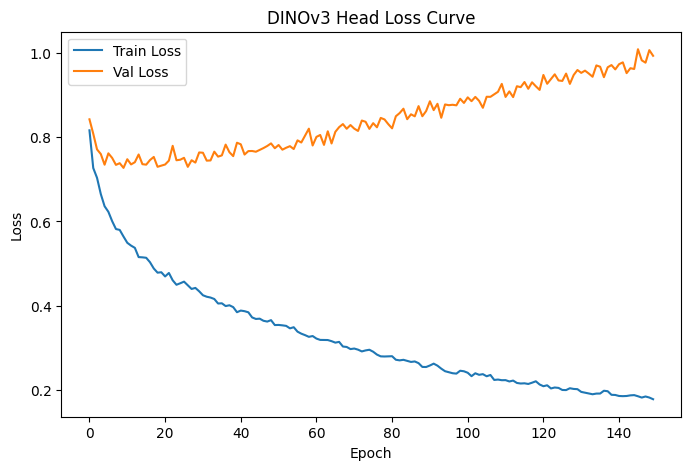

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DINOv3 Head Loss Curve")
plt.legend()

plt.show()

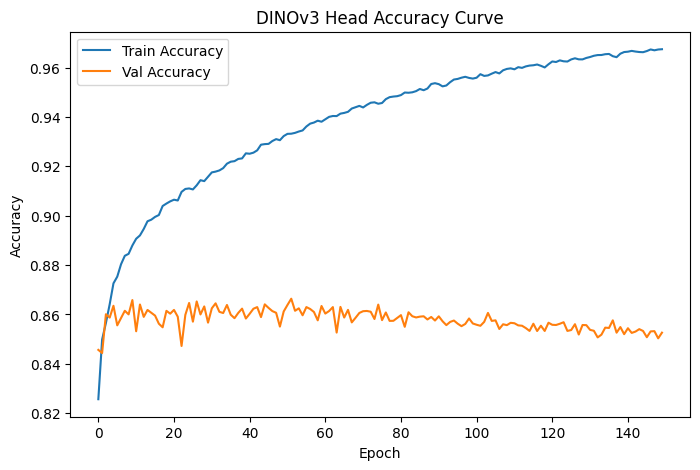

In [121]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Val Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DINOv3 Head Accuracy Curve")
plt.legend()

plt.show()

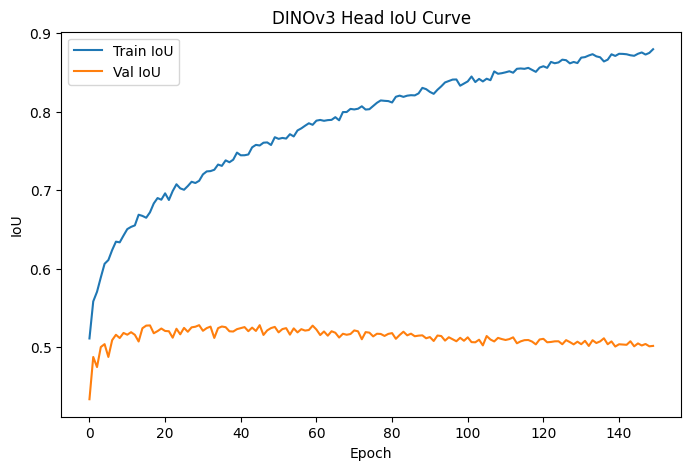

In [120]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Val IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("DINOv3 Head IoU Curve")
plt.legend()

plt.show()